# 컴퓨터 비전

### 담당교수 : 장원중

#### 그래프 한글이 깨질때 & 마이너스 부호 사용

In [1]:
import sys, os
from matplotlib import font_manager, rc 
import matplotlib.pyplot as plt

# 한글 폰트 설정 : 윈도우 폰트를 사용하는 경우 
# font_name = font_manager.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
# rc('font', family=font_name) 

# 운영체제별 한글 폰트 설정
if os.name == 'posix': # Mac 환경 폰트 설정
    rc('font', family='AppleGothic')
elif os.name == 'nt': # Windows 환경 폰트 설정
    rc('font', family='Malgun Gothic')

plt.rc('axes', unicode_minus=False) # 마이너스 폰트 설정

# 유니코드에서 음수 부호설정
rc('axes', unicode_minus=False)

# 부모 디렉터리의 파일을 가져올 수 있도록 설정
sys.path.append(os.pardir)     

# jupyter에서 matplotlib 그래프를 출력 영역에 표시  
%matplotlib inline 

# 레티나 설정 - 폰트 주변이 흐릿하게 보이는 것을 방지해 글씨가 좀 더 선명하게 보임
%config InlineBackend.figure_format = 'retina'

In [2]:
# 운영체제별 이름 

import platform

platform.system()

'Windows'

# 이미지 필터링

## 이미지에 필터를 쒸워보기

In [7]:
# np.ones()는 1로 가득찬 array를 생성한다.
#  - np.ones(shape, dtype, order)

# 3x3 행렬의 커널 : 주변 8개와 자기자신 픽셀의 평균(9개 픽셀의 평균)  

import numpy as np 

kernal1 = np.ones((3,3), np.float32) / 9   # 주변 8개와 자기자신 픽셀과의 평균(9개의 평균)을 계산 
kernal1
# array([[0.11111111, 0.11111111, 0.11111111],
#        [0.11111111, 0.11111111, 0.11111111],
#        [0.11111111, 0.11111111, 0.11111111]], dtype=float32)

array([[0.11111111, 0.11111111, 0.11111111],
       [0.11111111, 0.11111111, 0.11111111],
       [0.11111111, 0.11111111, 0.11111111]], dtype=float32)

In [9]:
# 3x3 행렬의 커널, 9x9 행렬의 커널

kernal1 = np.ones((3,3), np.float32) / 9   # 주변 8개와 자기자신 픽셀과의 평균(9개의 평균)을 계산 
print(kernal1)
# [[0.11111111 0.11111111 0.11111111]
#  [0.11111111 0.11111111 0.11111111]
#  [0.11111111 0.11111111 0.11111111]]

kernal2 = np.ones((9,9), np.float32) / 81  # 주변 80개와 자기자신 픽셀과의 평균(81개의 평균)을 계산 
print(kernal2)
# [[0.01234568 0.01234568 0.01234568 0.01234568 0.01234568 0.01234568 0.01234568 0.01234568 0.01234568]
# ...  

[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]
[[0.01234568 0.01234568 0.01234568 0.01234568 0.01234568 0.01234568
  0.01234568 0.01234568 0.01234568]
 [0.01234568 0.01234568 0.01234568 0.01234568 0.01234568 0.01234568
  0.01234568 0.01234568 0.01234568]
 [0.01234568 0.01234568 0.01234568 0.01234568 0.01234568 0.01234568
  0.01234568 0.01234568 0.01234568]
 [0.01234568 0.01234568 0.01234568 0.01234568 0.01234568 0.01234568
  0.01234568 0.01234568 0.01234568]
 [0.01234568 0.01234568 0.01234568 0.01234568 0.01234568 0.01234568
  0.01234568 0.01234568 0.01234568]
 [0.01234568 0.01234568 0.01234568 0.01234568 0.01234568 0.01234568
  0.01234568 0.01234568 0.01234568]
 [0.01234568 0.01234568 0.01234568 0.01234568 0.01234568 0.01234568
  0.01234568 0.01234568 0.01234568]
 [0.01234568 0.01234568 0.01234568 0.01234568 0.01234568 0.01234568
  0.01234568 0.01234568 0.01234568]
 [0.01234568 0.01234568 0.01234568 0.01234568 0.01234568 0.

In [5]:
# 커널을 특정 이미지에 적용하는 방법은 filter2D() 함수를 사용하면 된다.
# cv2.filter2D(src, ddepth, kernel[, dst[, anchor[, delta[, borderType]]]])
#   - ddepth : 이미지 깊이로 -1을 주면 주어진 입력 이미지와 동일한 값이 된다.  

# 다음은 3x3 행렬의 커널과 9x9 행렬의 커널을 적용하여 이미지를 변형하기 

import cv2 
import numpy as np 

org = cv2.imread(os.getcwd()+'/images/mandrill.png', 1)
print(org.shape)                              # (256, 256, 3) 
print(org[:1, :1, :])                         # [[[ 56 107 117]]] 

averaged33 = cv2.filter2D(org, -1, kernal1)   # 3x3 행렬의 커널 적용 
print(averaged33.shape)                       # (256, 256, 3)
print(averaged33[:1, :1, :])                  # [[[46 79 89]]]

averaged99 = cv2.filter2D(org, -1, kernal2)   # 9x9 행렬의 커널 적용  
print(averaged99.shape)                       # (256, 256, 3)
print(averaged99[:1, :1, :])                  # [[[47 83 94]]]

(256, 256, 3)
[[[ 56 107 117]]]
(256, 256, 3)
[[[46 79 89]]]
(256, 256, 3)
[[[47 83 94]]]


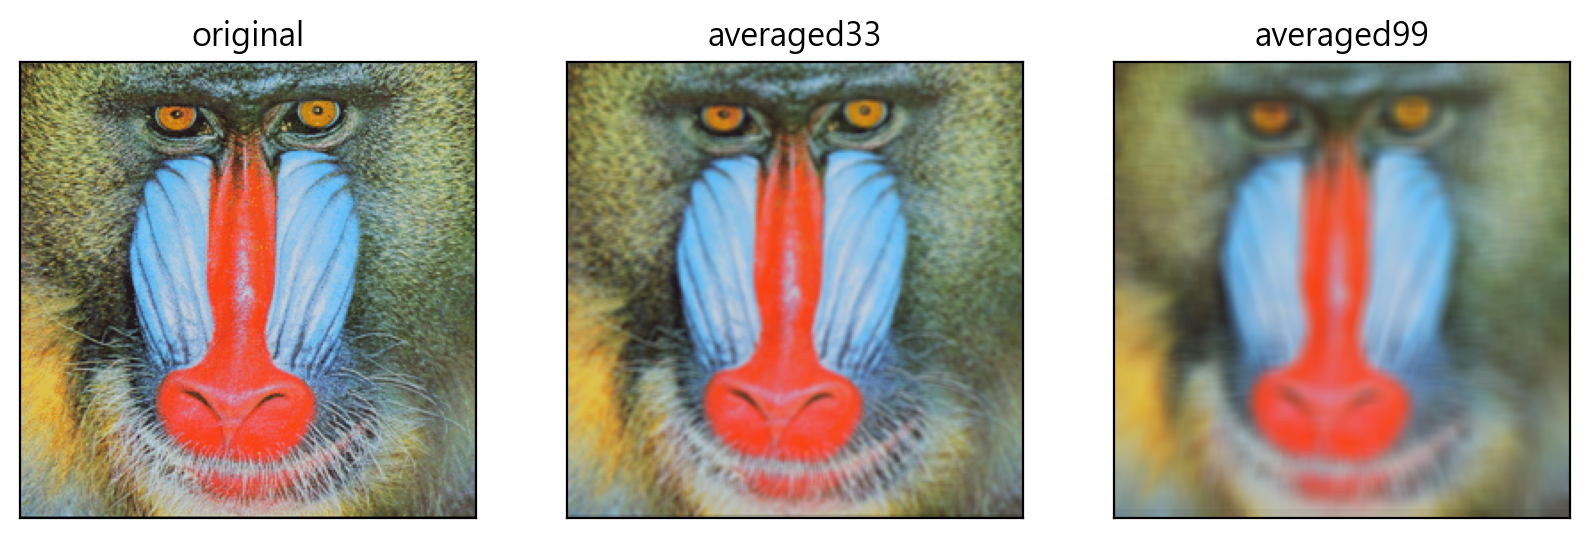

In [11]:
# 커널을 특정 이미지에 적용하는 방법은 filter2D() 함수를 사용하면 된다.
# cv2.filter2D(src, ddepth, kernel[, dst[, anchor[, delta[, borderType]]]])
#   - ddepth : 이미지 깊이로 -1을 주면 주어진 입력 이미지와 동일한 값이 된다.  

# cv2.imread(fileName, flag) 
# cv2.IMREAD_COLOR : 이미지 파일을 Color로 읽어들입니다.
#                    투명한 부분은 무시되며, Default값입니다.
# cv2.IMREAD_GRAYSCALE : 이미지를 Grayscale로 읽어 들입니다. 
#                        실제 이미지 처리시 중간단계로 많이 사용합니다.
# cv2.IMREAD_UNCHANGED : 이미지파일을 alpha channel까지 포함하여 읽어 들입니다.
# 3개의 flag대신에 1, 0, -1을 사용해도 됩니다.

# 다음은 맨드릴 원숭이 이미지에 3x3 행렬의 커널(9개 픽셀의 평균)과 9x9 행렬의 커널(81개 픽셀의 평균)을 적용한 필터 예제

import cv2 
import numpy as np 
import matplotlib.pyplot as plt

org = cv2.imread(os.getcwd()+'/images/mandrill.png', cv2.IMREAD_COLOR)
org_rgb = cv2.cvtColor(org, cv2.COLOR_BGR2RGB) # RGB 모드로 변환
kernal1 = np.ones((3,3), np.float32) / 9       # 3x3 행렬의 커널(9개 픽셀의 평균) 
kernal2 = np.ones((9,9), np.float32) / 81      # 9x9 행렬의 커널(81개 픽셀의 평균)
averaged33 = cv2.filter2D(org, -1, kernal1)    # 3x3 행렬의 커널 적용 
averaged99 = cv2.filter2D(org, -1, kernal2)    # 9x9 행렬의 커널 적용  
averaged33_rgb = cv2.cvtColor(averaged33, cv2.COLOR_BGR2RGB) # RGB 모드로 변환
averaged99_rgb = cv2.cvtColor(averaged99, cv2.COLOR_BGR2RGB) # RGB 모드로 변환

plt.figure(figsize=(10, 10))
plt.subplot(131)
plt.imshow(org_rgb)
plt.title("original")
plt.xticks([])
plt.yticks([])
plt.subplot(132)
plt.imshow(averaged33_rgb)
plt.title("averaged33")
plt.xticks([])
plt.yticks([])
plt.subplot(133)
plt.imshow(averaged99_rgb)
plt.title("averaged99")
plt.xticks([])
plt.yticks([])
plt.show()

# cv2.imshow('original', org)
# cv2.imshow('filtered1', averaged33)
# cv2.imshow('filtered2', averaged99)
# cv2.waitKey(0)                      # 사용자 입력을 기다림 
# cv2.destroyAllWindows()             # 모든 창을 없애고 프로그램 종료 

### 상자 필터(box filter)

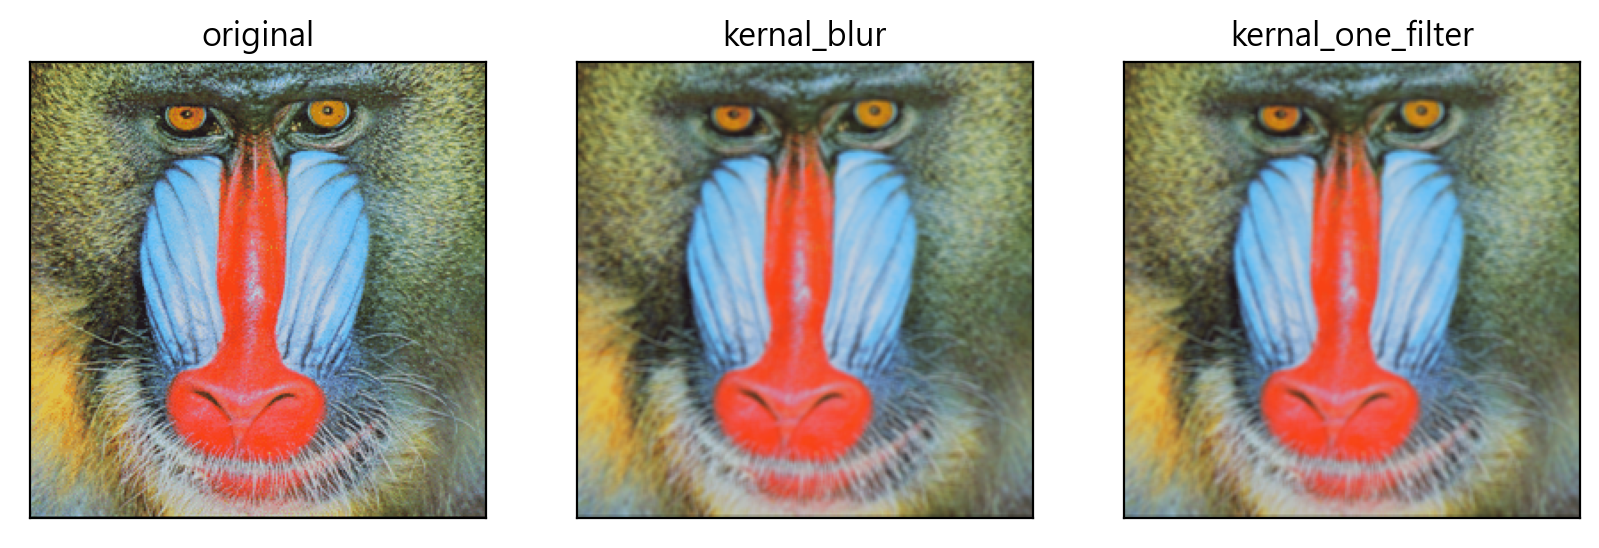

In [6]:
# 상자 필터(box filter) : 필터 중에서 특정 픽셀 주변의 픽셀들이 가진 값의 평균을 취하는 커널
#  - blur(image, filter_size)
#  - np.ones((n, n), np.float32) / (n*n)    

# 다음은 맨드릴 원숭이 이미지에 cv2 모듈의 blur() 함수와 numpy 모듈의 ones() 함수를 이용한 필터를 적용하는 코드

import cv2 
import numpy as np 
import matplotlib.pyplot as plt

org = cv2.imread(os.getcwd()+'/images/mandrill.png', cv2.IMREAD_COLOR)
org_rgb = cv2.cvtColor(org, cv2.COLOR_BGR2RGB) # RGB 모드로 변환

n = 3 
kernal_blur = cv2.blur(org, (n, n))
kernal_one = np.ones((n, n), np.float32) / (n*n) 
kernal_one_filter = cv2.filter2D(org, -1, kernal_one)
kernal_blur_rgb = cv2.cvtColor(kernal_blur, cv2.COLOR_BGR2RGB)             # RGB 모드로 변환
kernal_one_filter_rgb = cv2.cvtColor(kernal_one_filter, cv2.COLOR_BGR2RGB) # RGB 모드로 변환

plt.figure(figsize=(10, 10))
plt.subplot(131)
plt.imshow(org_rgb)
plt.title("original")
plt.xticks([])
plt.yticks([])
plt.subplot(132)
plt.imshow(kernal_blur_rgb)
plt.title("kernal_blur")
plt.xticks([])
plt.yticks([])
plt.subplot(133)
plt.imshow(kernal_one_filter_rgb)
plt.title("kernal_one_filter")
plt.xticks([])
plt.yticks([])
plt.show()

# cv2.imshow('original', org)              # 원본 이미지 
# cv2.imshow('blur filtered', kernal_blur) # blur() 함수를 사용한 필터로 변형한 이미지  
# cv2.imshow('ones filtered', avged33_one) # ones() 함수를 사용한 필터로 변형한 이미지 
# cv2.waitKey(0)                           # 사용자 입력을 기다림 
# cv2.destroyAllWindows()                  # 모든 창을 없애고 프로그램 종료 

## OpenCV로 이미지 필터링하기 : 가우스 필터

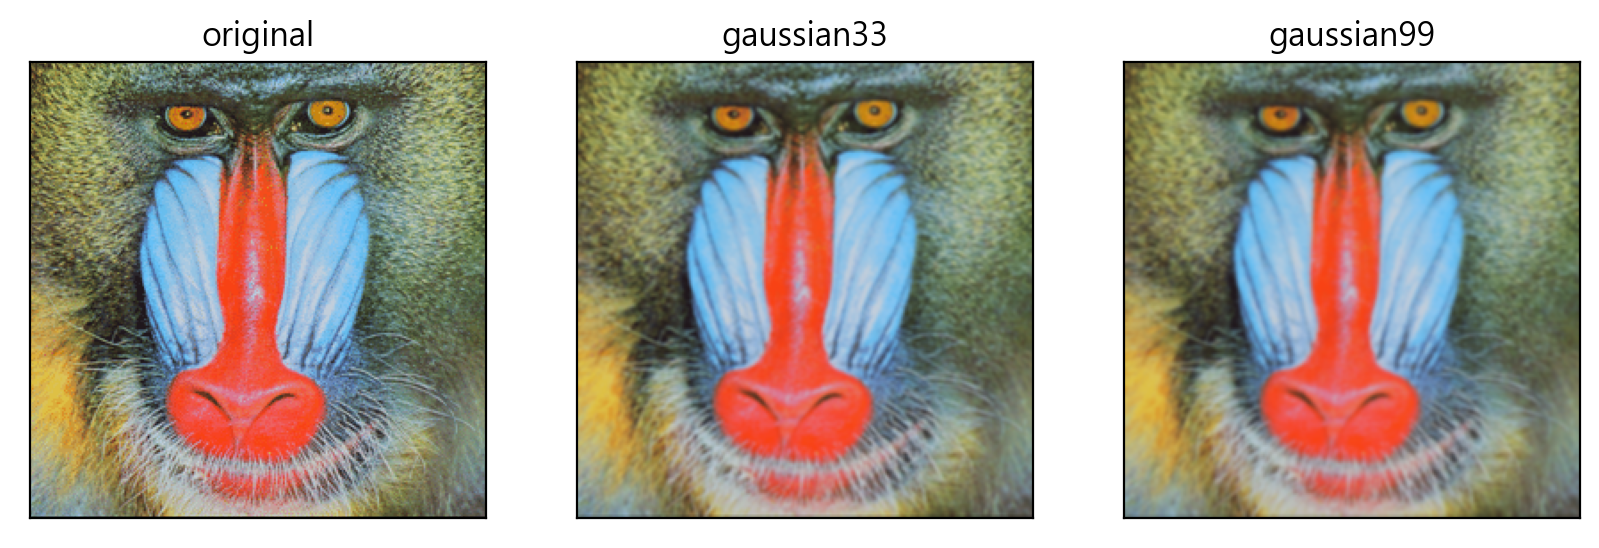

In [7]:
# 가우스 함수는 다음 그림처럼 종 모양(bell shaped) 함수 혹은 정규분포(normal distribution) 함수로 잘 알려져 있다. 
# OpenCV는 이러한 가우스 필터를 자동으로 적용할 수 있는 GaussianBlur() 함수를 제공한다. 
# dst = cv2.GaussianBlur(src, ksize, sigmaX[, dst[, sigmaY[, borderType]]]) 
#   - src 인자는 입력 이미지이다. 
#   - ksize 인자는 커널의 크기이고, 이 값에 n을 인자로 주면 n x n 크기의 커널을 가우스 함수에 근거하여 자동으로 생성한다.  
#   - sigmaX 인자는 x축 방향으로의 정규분포 표준편차(standard deviation)이고, 이 값에 따라 가우스 함수의 모양이 달라진다. 
#   - dst 인자는 결과가 출력될 이미지이다.  
#   - sigmaY 인자는 y축 표준편차인데 기본값은 0이고, 이 값이 0이면 x축 표준편차와 같은 값으로 처리된다. 

# 다음은 맨드릴 원숭이 이미지에 cv2 모듈의 GaussianBlur() 함수를 이용한 가우스 필터를 적용한 예제

import cv2, os 
import matplotlib.pyplot as plt

org = cv2.imread(os.getcwd()+'/images/mandrill.png', cv2.IMREAD_COLOR)
org_rgb = cv2.cvtColor(org, cv2.COLOR_BGR2RGB)    # RGB 모드로 변환

gaussian33 = cv2.GaussianBlur(org, (3,3), 1)      # n=3, x축 표준편차=1
gaussian99 = cv2.GaussianBlur(org, (9,9), 1)      # n=9, x축 표준편차=1
gaussian33_rgb = cv2.cvtColor(gaussian33, cv2.COLOR_BGR2RGB) # RGB 모드로 변환
gaussian99_rgb = cv2.cvtColor(gaussian99, cv2.COLOR_BGR2RGB) # RGB 모드로 변환

plt.figure(figsize=(10, 10))
plt.subplot(131)
plt.imshow(org_rgb)
plt.title("original")
plt.xticks([])
plt.yticks([])
plt.subplot(132)
plt.imshow(gaussian33_rgb)
plt.title("gaussian33")
plt.xticks([])
plt.yticks([])
plt.subplot(133)
plt.imshow(gaussian99_rgb)
plt.title("gaussian99")
plt.xticks([])
plt.yticks([])
plt.show()

# cv2.imshow('original', org)
# cv2.imshow('Gaussian 33', averaged33)
# cv2.imshow('Gaussian 99', averaged99)
# cv2.waitKey(0)                      # 사용자 입력을 기다림 
# cv2.destroyAllWindows()             # 모든 창을 없애고 프로그램 종료 

## 다양한 흐림 필터로 잡음을 제거하기

### 중앙값 필터 

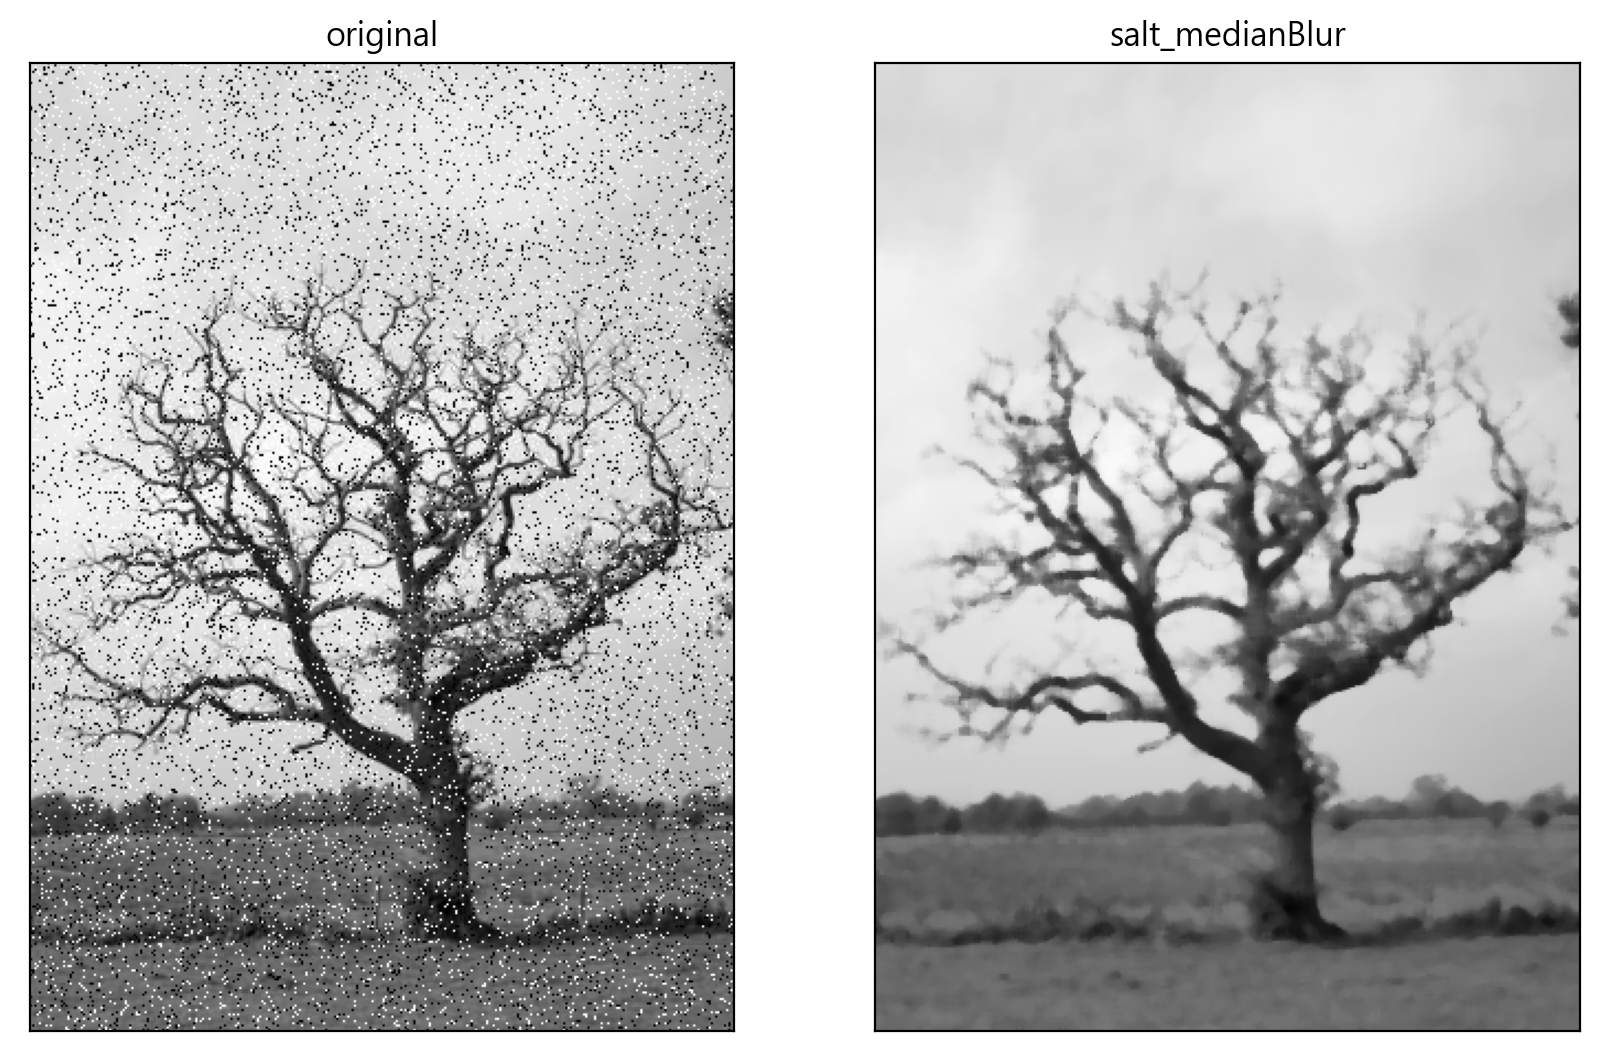

In [8]:
# medianBlur() 함수는 중앙값 흐림(median blur)을 수행하는 함수로 두 개의 매개변수를 가진다. 
# medianBlur(src, ksize[, dst])
#   - src 인자는 입력 이미지이다. 
#   - ksize 인자는 정수 n을 인자로 받고, n x n 크기의 필터 영역에서 중앙값(median)을 찾아 그 값으로 픽셀을 설정하는 것이다.

# 다음은 cv2 모듈의 medianBlur() 함수를 이용한 흐림 처리를 한 뒤의 결과를 비교해 보는 예제

import cv2, os 
import matplotlib.pyplot as plt

org_img = cv2.imread(os.getcwd()+'/images/salt_pepper.png', 0)
org_rgb = cv2.cvtColor(org_img, cv2.COLOR_BGR2RGB)                   # RGB 모드로 변환
salt_medBlur_img = cv2.medianBlur(org_rgb, 5)                        # 중앙값 흐림(5x5 크기의 필터)
salt_medBlur_rgb = cv2.cvtColor(salt_medBlur_img, cv2.COLOR_BGR2RGB) # RGB 모드로 변환

plt.figure(figsize=(10, 10))
plt.subplot(121)
plt.imshow(org_rgb)
plt.title("original")
plt.xticks([])
plt.yticks([])
plt.subplot(122)
plt.imshow(salt_medBlur_img)
plt.title("salt_medianBlur")
plt.xticks([])
plt.yticks([])
plt.show()

# cv2.imshow('original', org_img)
# cv2.imshow('median blurring', salt_pepper_img)
# cv2.waitKey(0)                      # 사용자 입력을 기다림 
# cv2.destroyAllWindows()             # 모든 창을 없애고 프로그램 종료 

### 양방향 필터 

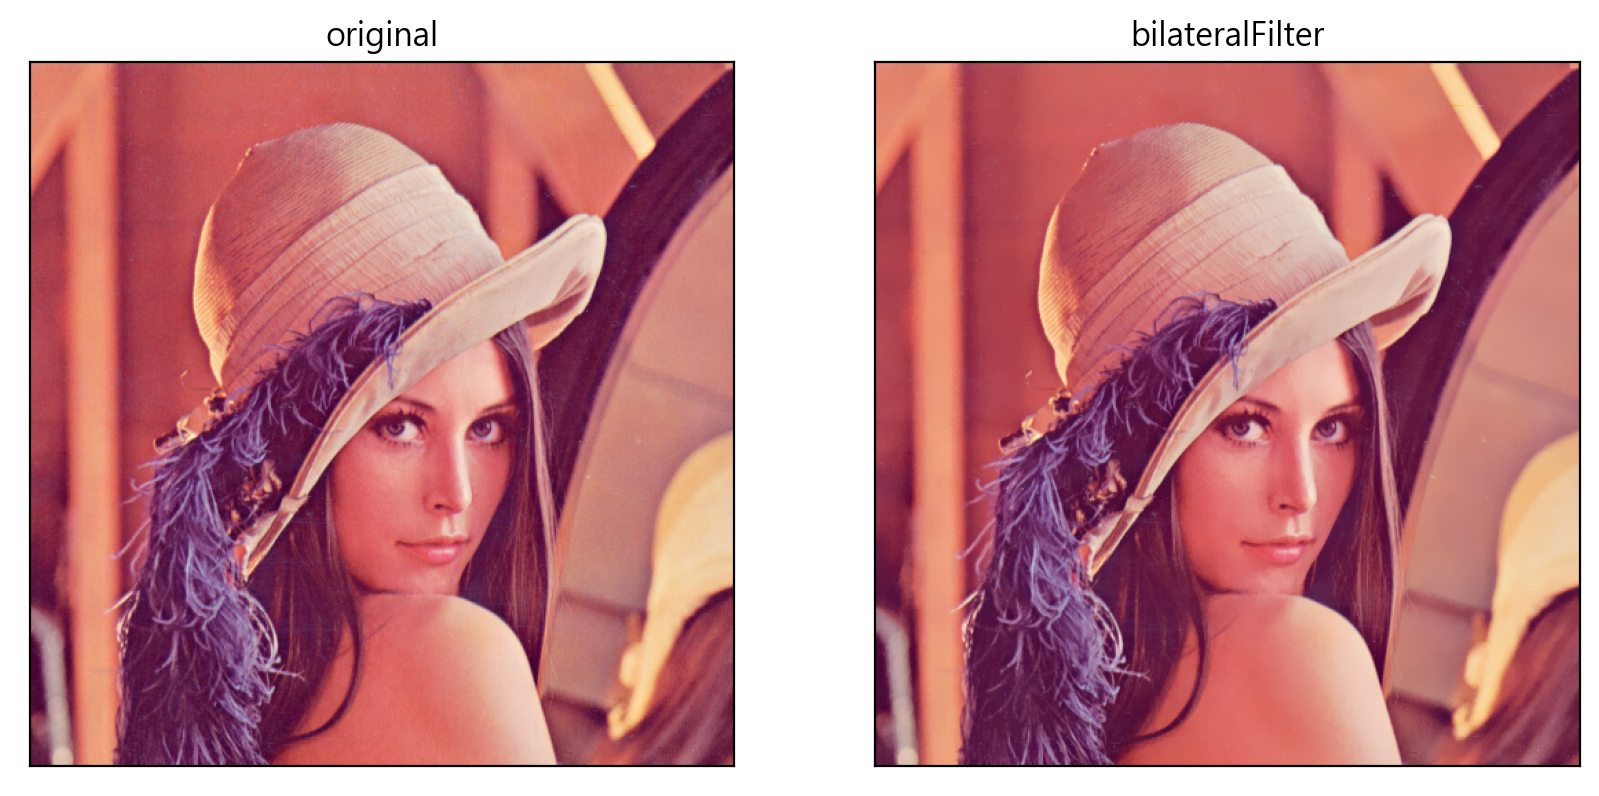

In [9]:
# cv2.bilateralFilter(src, d, sigmaColor, sigmaSpace, dst=None, borderType=None) -> dst
#  - src: 입력 영상. 8비트 또는 실수형, 1채널 또는 3채널.
#  - d: 필터링에 사용될 이웃 픽셀의 거리(지름), 음수(-1)를 입력하면 sigmaSpace 값에 의해 자동 결정(권장)
#  - sigmaColor: 색 공간에서 필터의 표준 편차
#  - sigmaSpace: 좌표 공간에서 필터의 표준 편차
#  - dst: 출력 영상. src와 같은 크기, 같은 타입.
#  - borderType: 가장자리 픽셀 처리 방식

import cv2, sys, os  
import matplotlib.pyplot as plt

org = cv2.imread(os.getcwd()+'/images/lena_color.tiff')
org_rgb = cv2.cvtColor(org, cv2.COLOR_BGR2RGB)     # RGB 모드로 변환

if org is None:
    print('Image load failed!')
    sys.exit()

dst_img = cv2.bilateralFilter(org, -1, 10, 5)      # 양방향 필터 
dst_rgb = cv2.cvtColor(dst_img, cv2.COLOR_BGR2RGB) # RGB 모드로 변환

plt.figure(figsize=(10, 10))
plt.subplot(121)
plt.imshow(org_rgb)
plt.title("original")
plt.xticks([])
plt.yticks([])
plt.subplot(122)
plt.imshow(dst_rgb)
plt.title("bilateralFilter")
plt.xticks([])
plt.yticks([])
plt.show()

# cv2.imshow('src', src)                      # 원본 이미지  
# cv2.imshow('dst', dst)                      # 양방향 필터를 적용한 이미지 
# cv2.waitKey()                               # 사용자 입력을 기다림 
# cv2.destroyAllWindows()                     # 모든 창을 없애고 프로그램 종료 

### 원본 이미지, 가우시안 필터 적용 이미지, 중앙값 필터 적용 이미지, 양방향 필터 적용 이미지 비교 

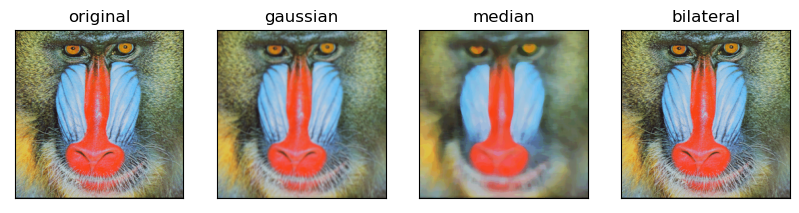

In [1]:
# 다음은 cv2 모듈의  medianBlur(), GaussianBlur(), bilateralFilter() 함수를 이용한 효과를 비교해 보는 예제

import cv2, os
import matplotlib.pyplot as plt

org_img = cv2.imread(os.getcwd()+'/images/mandrill.png', 1)
org_rgb = cv2.cvtColor(org_img, cv2.COLOR_BGR2RGB)               # RGB 모드로 변환

if org_img is None:
    print('Image load failed!')
    sys.exit()

gaussian_image = cv2.GaussianBlur(org_img, (9,9), 1)             # 가우시안 흐림 : n=9, x축 표준편차=1
median_image = cv2.medianBlur(org_img, 9)                        # 중앙값 흐림 : 9x9 
bilateral_image = cv2.bilateralFilter(org_img, -1, 10, 5)        # 양방향 필터 : 
gaussian_rgb = cv2.cvtColor(gaussian_image, cv2.COLOR_BGR2RGB)   # RGB 모드로 변환
median_rgb = cv2.cvtColor(median_image, cv2.COLOR_BGR2RGB)       # RGB 모드로 변환
bilateral_rgb = cv2.cvtColor(bilateral_image, cv2.COLOR_BGR2RGB) # RGB 모드로 변환

plt.figure(figsize=(10, 10))
plt.subplot(141)
plt.imshow(org_rgb)
plt.title("original")
plt.xticks([])
plt.yticks([])
plt.subplot(142)
plt.imshow(gaussian_rgb)
plt.title("gaussian")
plt.xticks([])
plt.yticks([])
plt.subplot(143)
plt.imshow(median_rgb)
plt.title("median")
plt.xticks([])
plt.yticks([])
plt.subplot(144)
plt.imshow(bilateral_rgb)
plt.title("bilateral")
plt.xticks([])
plt.yticks([])
plt.show()

# cv2.imshow('original', org_img)
# cv2.imshow('Gaussian', gaussian_image)
# cv2.imshow('Median', median_image)
# cv2.imshow('BilaterFilter', bilateral_image)
# cv2.waitKey()                                              # 사용자 입력을 기다림 
# cv2.destroyAllWindows()                                    # 모든 창을 없애고 프로그램 종료 

## 이미지에서 관심 있는 곳만 남겨보기

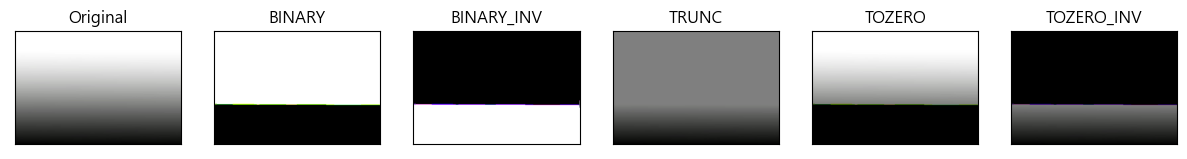

In [5]:
# cv2.threshold(src, thresh, maxval, type) → retval, dst
#  - src – input image로 single-channel 이미지.(grayscale 이미지)
#  - thresh – 임계값
#  - maxval – 임계값을 넘었을 때 적용할 value
#  - type – thresholding type

# cv2 모듈의 threshold() 함수를 이용해 임계치로 회색조 이미지를 이진화하여 비교해 보자.

import cv2, sys, os
import numpy as np
from matplotlib import pyplot as plt

org_img = cv2.imread(os.getcwd()+'/images/gray_gradient.jpg')

if org_img is None:
    print('Image load failed!')
    sys.exit()

ret, thresh1 = cv2.threshold(org_img, 127, 255, cv2.THRESH_BINARY)
ret, thresh2 = cv2.threshold(org_img, 127, 255, cv2.THRESH_BINARY_INV)
ret, thresh3 = cv2.threshold(org_img, 127, 255, cv2.THRESH_TRUNC)
ret, thresh4 = cv2.threshold(org_img, 127, 255, cv2.THRESH_TOZERO)
ret, thresh5 = cv2.threshold(org_img, 127, 255, cv2.THRESH_TOZERO_INV)

titles =['Original','BINARY','BINARY_INV','TRUNC','TOZERO','TOZERO_INV']
images = [org_img,thresh1,thresh2,thresh3,thresh4,thresh5]

plt.figure(figsize=(15,15))
for i in range(6):
    plt.subplot(1,6,i+1), plt.imshow(images[i],'gray'), plt.title(titles[i]), plt.xticks([]), plt.yticks([])

plt.show()

In [2]:
# cv2.threshold(src, thresh, maxval, type) → retval, dst
#  - src – input image로 single-channel 이미지.(grayscale 이미지)
#  - thresh – 임계값
#  - maxval – 임계값을 넘었을 때 적용할 value
#  - type – thresholding type

# 다음은 cv2 모듈의 threshold() 함수를 이용해 여러 개의 초가 켜져 있는 이미지에서 촛불만 추출해 보는 예제
#   - 트랙바가 변경되면 그 값을 임계치로 회색조 이미지를 이진화하여 창에 그림 

import cv2, sys, os 

global color_image, gray_image 

# 트랙바가 변경되면 그 값을 임계치로 회색조 이미지를 이진화하여 창에 그림 
#  - THRESH_BINARY : 조건을 만족하는 픽셀값을 최댓값으로 만족하지 않는 픽셀 값을 0(검정색)으로 설정
#  - 회색조 이미지 사용 
def on_change_threshold(x):
    _, th_image = cv2.threshold(gray_image, x, 255, cv2.THRESH_BINARY)
    cv2.imshow('Thresholding', th_image)

# 윈도우를 생성함
cv2.namedWindow('Thresholding')    
cv2.createTrackbar('threshold', 'Thresholding', 0, 255, on_change_threshold)
 
# 촛불 이미지를 읽고, 회색조 이미지를 준비함 
color_image = cv2.imread(os.getcwd()+'/images/candles.jpg', cv2.IMREAD_COLOR)
gray_image = cv2.cvtColor(color_image, cv2.COLOR_BGR2GRAY)

# 처음에는 원본 이미지를 그림(트랙바를 변경하면 임계치에 따라 이진화 결과 출력)
cv2.imshow('Thresholding', color_image)
cv2.waitKey()                           # 사용자 입력을 기다림 
cv2.destroyAllWindows()                 # 모든 창을 없애고 프로그램 종료 

In [13]:
# 다음은 cv2 모듈의 threshold() 함수를 이용해 여러 개의 초가 켜져 있는 이미지에서 촛불만 추출해 보는 예제
#   - 트랙바가 변경되면 그 값을 임계치로 원본 컬러 이미지를 이진화하여 창에 그림 

import cv2, sys, os

global color_image, gray_image 

# 트랙바가 변경되면 그 값을 임계치로 원본 컬러 이미지를 이진화하여 창에 그림 
#  - THRESH_BINARY : 조건을 만족하는 픽셀값을 최댓값으로 만족하지 않는 픽셀 값을 0(검정색)으로 설정
#  - 컬러 이미지 사용 
def on_change_threshold(x):
    _, th_image = cv2.threshold(color_image, x, 255, cv2.THRESH_BINARY)
    cv2.imshow('Thresholding', th_image)

# 윈도우를 생성함
cv2.namedWindow('Thresholding')    
cv2.createTrackbar('threshold', 'Thresholding', 0, 255, on_change_threshold)
 
# 촛불 이미지를 읽고, 회색조 이미지를 준비함 
color_image = cv2.imread(os.getcwd()+'/images/candles.jpg', cv2.IMREAD_COLOR)
gray_image = cv2.cvtColor(color_image, cv2.COLOR_BGR2GRAY)

# 처음에는 원본 이미지를 그림(트랙바를 변경하면 임계치에 따라 이진화 결과 출력)
cv2.imshow('Thresholding', color_image)
cv2.waitKey()                            # 사용자 입력을 기다림 
cv2.destroyAllWindows()                  # 모든 창을 없애고 프로그램 종료 

## 이미지 윤관선을 더 잘 뽑아 내기

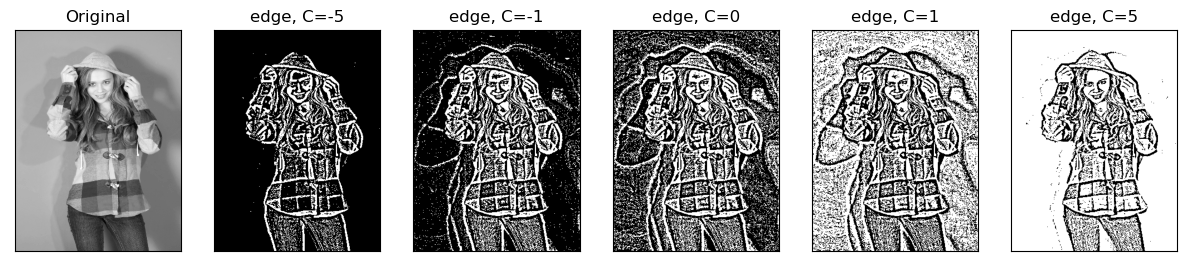

In [4]:
# cv2.adaptiveThreshold(src, maxValue, adaptiveMethod, thresholdType, blockSize, C)
#  - src – grayscale image
#  - maxValue – 임계값
#  - adaptiveMethod – thresholding value를 결정하는 계산 방법
#  - thresholdType – threshold type
#  - blockSize – thresholding을 적용할 영역 사이즈
#  - C – 평균이나 가중평균에서 차감할 값

# 다음은 cv2 모듈의 적응적 임계값(adaptiveThreshold()) 함수를 이용해 이미지의 윤곽선을 추출해 보는 예제이다.
#   - 구역 내의 픽셀 평균값(=ADAPTIVE_THRESH_MEAN_C)  
#   - (C(=0, -1, 1, -5, 5)의 값을 변경하면서 그려보자)

import cv2 
from matplotlib import pyplot as plt
import sys, os

# image를 회색조로 읽어들인다. 
color_image = cv2.imread(os.getcwd()+'/images/green_back.png', cv2.IMREAD_COLOR)
image_gray = cv2.cvtColor(color_image, cv2.COLOR_BGR2GRAY)

def img_adaptiveThreshold(x) :
    return cv2.adaptiveThreshold(src=image_gray, 
                                      maxValue=255, 
                                      adaptiveMethod=cv2.ADAPTIVE_THRESH_MEAN_C,
                                      thresholdType=cv2.THRESH_BINARY,
                                      blockSize=9,
                                      C=x)

# adaptiveThreshold를 적용한다. 
#  - 주변 9x9 픽셀 공간의 평균값-C가 임계치가 되고, 이보다 크면 255, 그렇지 않으면 0 
#  - C = -5, -1, 0, 1, 5의 값으로 설정 

image_edge_m5 = img_adaptiveThreshold(-5)
image_edge_m1 = img_adaptiveThreshold(-1)
image_edge_ze = img_adaptiveThreshold(0)
image_edge_p1 = img_adaptiveThreshold(1)
image_edge_p5 = img_adaptiveThreshold(5)

titles =['Original','edge, C=-5','edge, C=-1','edge, C=0','edge, C=1','edge, C=5']
images = [image_gray,image_edge_m5,image_edge_m1,image_edge_ze,image_edge_p1,image_edge_p5]

plt.figure(figsize=(15,15))
for i in range(6):
    plt.subplot(1,6,i+1), plt.imshow(images[i], 'gray'), plt.title(titles[i]), plt.xticks([]), plt.yticks([])

plt.show()

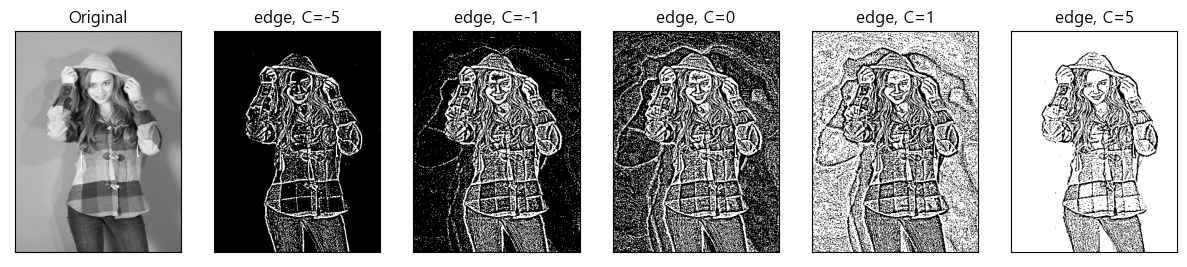

In [12]:
# cv2.adaptiveThreshold(src, maxValue, adaptiveMethod, thresholdType, blockSize, C)
#  - src – grayscale image
#  - maxValue – 임계값
#  - adaptiveMethod – thresholding value를 결정하는 계산 방법
#  - thresholdType – threshold type
#  - blockSize – thresholding을 적용할 영역 사이즈
#  - C – 평균이나 가중평균에서 차감할 값

# 다음은 cv2 모듈의 적응적 임계값(adaptiveThreshold()) 함수를 이용해 이미지의 윤곽선을 추출해 보는 예제이다.
#   - 구역 내의 픽셀에 가우스 가중치(=ADAPTIVE_THRESH_GAUSSIAN_C)  
#   - (C(=0, -1, 1, -5, 5)의 값을 변경하면서 그려보자)

import cv2 
from matplotlib import pyplot as plt
import sys, os

# image를 회색조로 읽어들인다. 
color_image = cv2.imread(os.getcwd()+'/images/green_back.png', cv2.IMREAD_COLOR)
image_gray = cv2.cvtColor(color_image, cv2.COLOR_BGR2GRAY)

def img_adaptiveThreshold(x) :
    return cv2.adaptiveThreshold(src=image_gray, 
                                      maxValue=255, 
                                      adaptiveMethod=cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                      thresholdType=cv2.THRESH_BINARY,
                                      blockSize=9,
                                      C=x)

# adaptiveThreshold를 적용한다. 
#  - 주변 9x9 픽셀 공간의 평균값-C가 임계치가 되고, 이보다 크면 255, 그렇지 않으면 0 
#  - C = -5, -1, 0, 1, 5의 값으로 설정 

image_edge_m5 = img_adaptiveThreshold(-5)
image_edge_m1 = img_adaptiveThreshold(-1)
image_edge_ze = img_adaptiveThreshold(0)
image_edge_p1 = img_adaptiveThreshold(1)
image_edge_p5 = img_adaptiveThreshold(5)

titles =['Original','edge, C=-5','edge, C=-1','edge, C=0','edge, C=1','edge, C=5']
images = [image_gray,image_edge_m5,image_edge_m1,image_edge_ze,image_edge_p1,image_edge_p5]

plt.figure(figsize=(15,15))
for i in range(6):
    plt.subplot(1,6,i+1), plt.imshow(images[i], 'gray'), plt.title(titles[i]), plt.xticks([]), plt.yticks([])

plt.show()

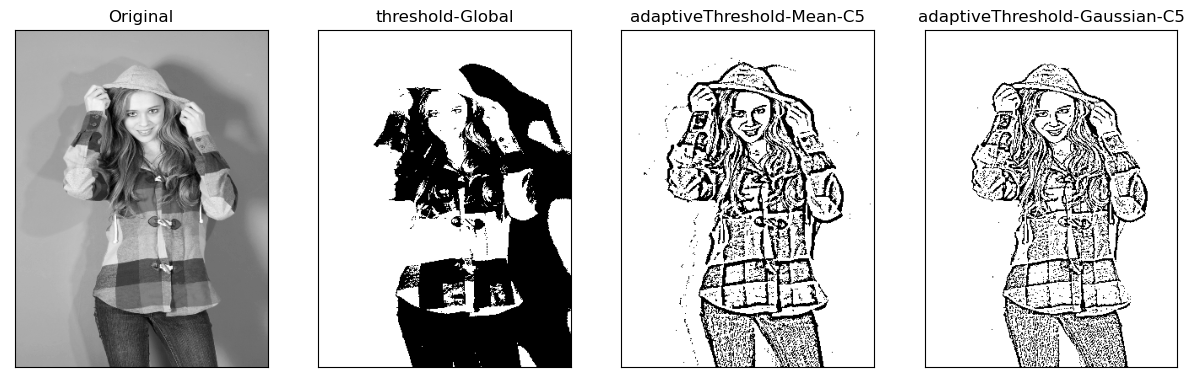

In [5]:
#  다음은 cv2 모듈의 threshold(), adaptiveThreshold() 함수를 이용해 이미지의 윤곽선을 추출해 보는 예제

import cv2, sys, os 
import numpy as np 
from matplotlib import pyplot as plt 

# image를 회색조로 읽어들인다. 
color_image = cv2.imread(os.getcwd()+'/images/green_back.png', cv2.IMREAD_COLOR)
image_gray = cv2.cvtColor(color_image, cv2.COLOR_BGR2GRAY)

ret, th1 = cv2.threshold(image_gray, 127, 255, cv2.THRESH_BINARY)
th2 = cv2.adaptiveThreshold(image_gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 9, 5)
th3 = cv2.adaptiveThreshold(image_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 9, 5)

titles = ['Original','threshold-Global','adaptiveThreshold-Mean-C5','adaptiveThreshold-Gaussian-C5']
images = [image_gray, th1, th2, th3]

plt.figure(figsize=(15,15))
for i in range(4):
    plt.subplot(1,4,i+1), plt.imshow(images[i],'gray'), plt.title(titles[i]), plt.xticks([]),plt.yticks([])

plt.show()